Daily gross order revenue, **excluding cancelled orders**, screened for days that
deviate from their own recent behaviour. Revenue itself is the governed dbt metric
(`models/semantic/_metrics.yml`); the screen is a robust z-score computed in this
notebook — a *method* applied to the metric, not a redefinition of it.

Both halves live on one page: the KPI row is Evidence SQL over the semantic layer,
and everything under "What the screen found" is pandas from this notebook.

In [1]:
# Make `import evidence` work from any notebook under pages/.
import sys, pathlib
for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (parent / "evidence.py").exists():
        sys.path.insert(0, str(parent))
        break

import evidence
import numpy as np
import pandas as pd

In [2]:
# Read the same parquet Evidence serves, so the notebook and the page
# can never disagree about what revenue was.
orders = pd.read_parquet(
    "../../.evidence/template/static/data/dbt_semantic/orders/orders.parquet"
)

daily = (
    orders.loc[orders["order_status"] != "cancelled"]
    .groupby("ordered_date", as_index=False)
    .agg(revenue=("order_amount_usd", "sum"), orders=("order_id", "count"))
    .rename(columns={"ordered_date": "order_date"})
    .sort_values("order_date")
    .reset_index(drop=True)
)

len(daily)

84

## The screen

Two decisions carry this analysis, and both are visible below.

**Deseasonalize first.** Day-of-week is the dominant signal in daily revenue — a
screen that skips this step just rediscovers the weekend, every weekend.

**Median absolute deviation, not standard deviation.** The outliers being hunted
would otherwise inflate the very threshold meant to catch them. The `0.6745`
factor rescales MAD onto a standard-deviation footing, so the cut-off reads like
a familiar z.

In [3]:
WINDOW = 28      # days of history each point is judged against
THRESHOLD = 3.5  # robust z beyond which a day is flagged

# Remove day-of-week seasonality before screening.
dow = pd.to_datetime(daily["order_date"]).dt.dayofweek
dow_factor = daily.groupby(dow)["revenue"].transform("median") / daily["revenue"].median()
daily["adjusted"] = daily["revenue"] / dow_factor

def robust_z(series: pd.Series, window: int = WINDOW) -> pd.Series:
    """Median-absolute-deviation z-score over a trailing window."""
    med = series.rolling(window, min_periods=14).median()
    mad = (series - med).abs().rolling(window, min_periods=14).median()
    return 0.6745 * (series - med) / mad.replace(0, np.nan)

rolling_median = daily["adjusted"].rolling(WINDOW, min_periods=14).median()
daily["expected"] = rolling_median * dow_factor
daily["robust_z"] = robust_z(daily["adjusted"])
daily["is_anomaly"] = daily["robust_z"].abs() >= THRESHOLD

anomalies = (
    daily.loc[daily["is_anomaly"]]
    .assign(
        gap=lambda d: d["revenue"] - d["expected"],
        direction=lambda d: np.where(d["robust_z"] < 0, "Below expected", "Above expected"),
    )
    .loc[:, ["order_date", "revenue", "expected", "gap", "robust_z", "direction"]]
)

print(f"{len(anomalies)} of {len(daily)} days flagged at |z| >= {THRESHOLD}")

2 of 84 days flagged at |z| >= 3.5


In [4]:
# Publish to the page. Each name becomes a variable that every Evidence
# component on this page can bind to.
evidence.data(daily, "daily")
evidence.data(anomalies, "anomalies")

## Revenue, as the semantic layer reports it

Trailing 28 days against the 28 before it. A 28-day window rather than a single
day so a partial final day cannot move the headline.

```sql revenue_kpi
with d as (
    select metric_time, sum(revenue) as revenue
    from ${metrics_revenue}
    group by 1
    having sum(revenue) > 0
),
bounds as (select max(metric_time) as as_of from d)
select
    b.as_of,
    sum(d.revenue) filter (
        where d.metric_time > b.as_of - interval 28 day
    ) as revenue_28d,
    sum(d.revenue) filter (
        where d.metric_time <= b.as_of - interval 28 day
          and d.metric_time > b.as_of - interval 56 day
    ) as prev_28d,
    count(*) filter (where d.metric_time > b.as_of - interval 28 day) as days_28d
from d cross join bounds b
group by b.as_of
```

```sql revenue_kpi_final
select
    as_of,
    revenue_28d,
    revenue_28d / nullif(days_28d, 0) as avg_daily_28d,
    (revenue_28d - prev_28d) / nullif(prev_28d, 0) as revenue_chg,
    (revenue_28d / nullif(days_28d, 0) - prev_28d / 28.0)
        / nullif(prev_28d / 28.0, 0) as avg_daily_chg
from ${revenue_kpi}
```

<Grid cols=2>
  <BigValue data={revenue_kpi_final} value=revenue_28d title="Revenue, trailing 28d" fmt=usd0k
    comparison=revenue_chg comparisonFmt=pct1 comparisonTitle="vs prior 28d"/>
  <BigValue data={revenue_kpi_final} value=avg_daily_28d title="Average day, trailing 28d" fmt=usd0
    comparison=avg_daily_chg comparisonFmt=pct1 comparisonTitle="vs prior 28d"/>
</Grid>

## What the screen found

`daily` and `anomalies` are pandas DataFrames published from this notebook — the
same Evidence components, bound to notebook data instead of SQL.

<LineChart data={daily} x=order_date y={["revenue", "expected"]} yFmt=usd0k
    title="Daily revenue against its rolling expectation"
    subtitle="Deseasonalized 28-day rolling median; flagged at |z| >= 3.5">
  <ReferenceLine x='2026-05-02' label="Largest deviation" color=negative/>
</LineChart>

<DataTable data={anomalies} rows=10>
  <Column id=order_date title="Date"/>
  <Column id=direction title="Direction"/>
  <Column id=revenue title="Actual" fmt=usd0/>
  <Column id=expected title="Expected" fmt=usd0/>
  <Column id=gap title="Gap" fmt=usd0 contentType=delta/>
  <Column id=robust_z title="Robust z" fmt=num1/>
</DataTable>

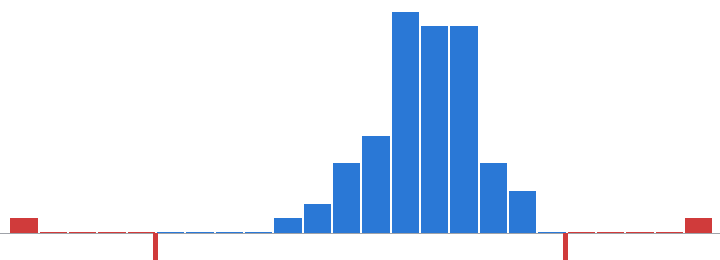

In [5]:
import matplotlib.pyplot as plt

# Transparent, so the figure sits on Evidence's light *and* dark surface.
plt.rcParams["savefig.transparent"] = True
plt.rcParams["figure.facecolor"] = "none"

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(daily["robust_z"].dropna(), bins=24, range=(-6, 6))
ax.axvline(THRESHOLD, linestyle="--")
ax.axvline(-THRESHOLD, linestyle="--")
ax.set_xlabel("robust z-score")
ax.set_ylabel("days")
fig.tight_layout()

The distribution is tight around zero and the flagged tail is thin — which is
what makes 3.5 a defensible cut-off rather than a knob tuned to taste.

In [6]:
anomalies.style.format({
    "revenue": "${:,.0f}", "expected": "${:,.0f}",
    "gap": "${:,.0f}", "robust_z": "{:.2f}",
})

order_date,revenue,expected,gap,robust_z,direction
2026-05-02,"$12,259","$29,062","$-16,803",-15.80,Below expected
2026-05-23,"$51,406","$31,230","$20,175",14.44,Above expected
